In [31]:
import torch
import torch.nn as nn
import networkx as nx
import json
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split
from train_sm import train_val_test_loaders, MakeDataset
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [14]:
data_dir = Path('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_samples_1e6/')
save_dir = Path('/gpfs/bwfor/work/ws/hd_gy283-my_data/data/')
save_dir.mkdir(exist_ok=True, parents=True)

n_a = 200
radius = 150.0
R = np.sqrt(np.pi * radius**2 / n_a)

output_idx = 0
num_batches = 5

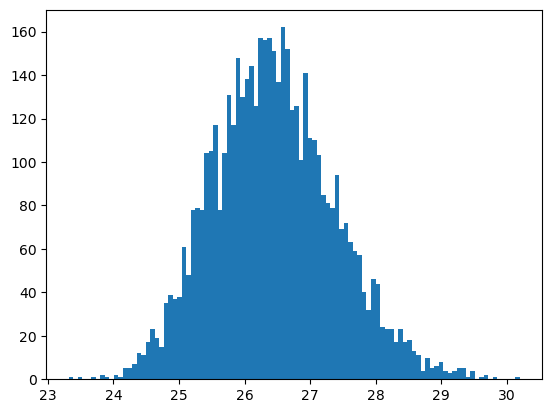

In [35]:
voltages = []
configurations = []
adj_matices = []
currents = []

for i in range(num_batches):

    fp = data_dir / f'batch_{i}.npz'
    try:
        batch = np.load(fp)
    except FileNotFoundError:
        continue        

    voltages.append(batch['inputs'])
    configurations.append(batch['acc_xy'])    
    adj_matices.append([a_ij[:n_a, :n_a] for a_ij in batch['adj_mat']])

    if batch['currents'].ndim != 1:
        currents.append(batch['currents'][:, output_idx])
    else:
        currents.append(batch['currents'])

V = np.concatenate(voltages)[:, [i for i in range(voltages[0].shape[1]) if i != output_idx]]
X = np.concatenate(configurations)
A = np.concatenate(adj_matices)
y = np.concatenate(currents)

avg_degrees = []
avg_clustering = []
for a_ij in A:
    num_nodes = a_ij.shape[0]
    num_edges = np.count_nonzero(np.triu(a_ij, k=1))
    
    avg_deg_i = 2*num_edges / num_nodes
    avg_degrees.append(avg_deg_i)

    g = nx.from_numpy_array(a_ij)
    avg_clst_i = nx.average_clustering(g)
    avg_clustering.append(avg_clst_i)

plt.hist(avg_degrees, bins=100)

X = X * R / radius

torch.save(
    {
        "V": V,
        "X": X,
        "A": A,
        "y": y,
        "radius": radius,
        "out_idx": output_idx
    },
    save_dir / f'dataset.pt'
)

In [37]:
data = torch.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/data/dataset.pt', weights_only=False, map_location='cpu')
print(data)

{'V': array([[-0.72723636, -0.23815907, -0.51943855, ...,  0.47772906,
         1.25098793, -1.30123612],
       [-0.24328141, -0.74249969, -0.97366521, ..., -1.03400525,
         1.2173852 , -1.49999186],
       [-0.6479919 , -1.08424379, -0.23281404, ...,  0.56073552,
         1.31084873, -1.31636121],
       ...,
       [-1.09331462, -0.12280582,  1.03754799, ...,  0.2989514 ,
         0.98114913, -1.36697998],
       [ 1.29445527,  0.15628695,  0.94297323, ..., -0.19980687,
         0.1385483 ,  0.1579382 ],
       [-1.21639681, -1.15715901,  0.21148053, ..., -0.7436142 ,
         1.10997621,  1.23229081]], shape=(5000, 7)), 'X': array([[[ 0.16992915,  0.46839178],
        [-0.24801007, -0.49675764],
        [ 0.36176726,  0.33478063],
        ...,
        [-0.55981046, -0.46597871],
        [-0.11456065,  0.93436274],
        [-0.30135498,  0.35198923]],

       [[ 0.65142909,  0.07085823],
        [-0.20266912, -0.70989362],
        [-0.18647945,  0.22815715],
        ...,
      

In [ ]:
print(X.shape)

X_train, X_val_test, V_train, V_val_test, y_train, y_val_test = train_test_split(X, V, y, train_size=train_size, random_state=np.random.randint(0, 2**31 - 1), shuffle=True)

X_val = X_val_test[:int(val_size*len_dataset), ...]
X_test = X_val_test[int(val_size*len_dataset):, ...]

V_val = V_val_test[:int(val_size*len_dataset), ...]
V_test = V_val_test[int(val_size*len_dataset):, ...]

y_val = y_val_test[:int(val_size*len_dataset), ...]
y_test = y_val_test[int(val_size*len_dataset):, ...]

v_mean = V_train.mean(0)
v_std = V_train.std(0)

y_mean = y_train.mean()
y_std = y_train.std()

noise_level = 0.01

if noise_level is not None and noise_level > 0.0:
    X_train = X_train + np.random.normal(loc=0.0, scale=noise_level, size=X_train.shape)
    V_train = V_train + np.random.normal(loc=0.0, scale=noise_level, size=V_train.shape)

class TwoInputDataset(Dataset):
    def __init__(self, X, V, y):
        
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.V = torch.as_tensor(V, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)

        if self.y.dim() == 1:
            self.y = self.y.unsqueeze(1)

        assert len(self.X) == len(self.V) == len(self.y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.V[idx], self.y[idx]

train_set = TwoInputDataset(X_train, V_train, y_train)
val_set = TwoInputDataset(X_val, V_val, y_val)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"train_set: {len(train_loader.dataset)}")
print(f"val_set: {len(val_loader.dataset)}")
print(f"test_set: {len(X_test)}")